In [67]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))
from constants import PROCESSED_DATA_FOLDER, ASSETS_FOLDER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from helpers import ModelData

In [68]:
from constants import DATA_FOLDER

# Dataframes
reviews = pd.read_csv(DATA_FOLDER / "reviews.csv")
business_covariates = pd.read_csv(DATA_FOLDER / "business_covariates.csv")

In [69]:
model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data_42.pkl")
model_data

ModelData(n_total=921, n_train=500, n_obs=64887)

In [70]:
reviews.head(2)

,review_id,business_id,user_id,date,stars,text,funny,cool,useful,Year,first_year,.groups,n_reviews,AggRat,language,tempcontiguity,sentimenttext,wordCount
0,EQF-SyHb_Yg0HC9E9BppOg,--g-a85VwrdZJNf0R95GcQ,SvsoiaCf0WG7UIDJOxJ7Yg,2013-11-14,5,super fresh food..great prices. ala carte and ...,0,1,3,2013,2013,drop,24,5.0,en,0,0.461132,10
1,qfvzHEL0gGxRdTo7NB2fnw,--g-a85VwrdZJNf0R95GcQ,D0YggUjK98hwIpiqXA9y_g,2013-11-18,5,I was in the Kabab House for the first time on...,0,1,3,2013,2013,drop,24,5.0,en,0,0.287281,44


In [71]:
# add closed column
business_covariates["Closed"] = 1 - business_covariates["is_open"]

business_covariates.head(2)

,business_id,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,...,density,TRAIN,category,FT,Price.Level,Restaurant.Size,Number.of.Seats,ZRI,Distance.To.City.Centre,Closed
0,QkG3KUXwqZBW18A9k1xqCA,"""Red Lobster""",NaN,"""2810 North 75th Ave""",Phoenix,AZ,85035.0,33.478735,-112.221379,2.5,...,11,0,American,False,2.0,700.0,350.0,1248.0,14035.314000,0
1,5XejqzaFmtkZMstJS5Iy-w,"""D'Lish Cafe""",NaN,"""503 W Thomas Rd""",Phoenix,AZ,85013.0,33.480301,-112.080586,4.0,...,17,0,American,False,1.0,200.0,30.0,1557.0,3279.013976,1


In [72]:
business_covariates_renamed = business_covariates.rename(
    columns={"stars": "overall_stars"}
)
df_joined = reviews.merge(business_covariates_renamed, on="business_id", how="left")
df_joined.columns

Index(['review_id', 'business_id', 'user_id', 'date', 'stars', 'text', 'funny',
       'cool', 'useful', 'Year', 'first_year', '.groups', 'n_reviews',
       'AggRat', 'language', 'tempcontiguity', 'sentimenttext', 'wordCount',
       'name', 'neighborhood', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'overall_stars', 'review_count', 'is_open',
       'categories', 'Checkin', 'chain', 'density', 'TRAIN', 'category', 'FT',
       'Price.Level', 'Restaurant.Size', 'Number.of.Seats', 'ZRI',
       'Distance.To.City.Centre', 'Closed'],
      dtype='object')

## Summary Statistics


In [73]:
########### Summary Statistics ###################
import pandas as pd

summary_data = {"Variable": [], "Mean": [], "SD": []}

# Rating level
summary_data["Variable"].append("Rating")
summary_data["Mean"].append(round(np.mean(model_data.ratings), 2))
summary_data["SD"].append(round(np.std(model_data.ratings, ddof=1), 2))

# Berechne Zeitdifferenzen zwischen Bewertungen
temp_diff = np.diff(model_data.days)
temp_diff = temp_diff[temp_diff >= 0]  # Negative Werte entfernen
summary_data["Variable"].append("Days Between Ratings")
summary_data["Mean"].append(round(np.mean(temp_diff), 2))
summary_data["SD"].append(round(np.std(temp_diff, ddof=1), 2))

# Sentiment statistics
summary_data["Variable"].append("Sentiment")
summary_data["Mean"].append(round(np.nanmean(model_data.sentiment), 2))
summary_data["SD"].append(round(np.nanstd(model_data.sentiment, ddof=1), 2))

# Restaurant Density
summary_data["Variable"].append("Density")
summary_data["Mean"].append(
    round(np.mean(model_data.business_covariates["density"]), 2)
)
summary_data["SD"].append(
    round(np.std(model_data.business_covariates["density"], ddof=1), 2)
)

# Age (in Monaten, daher / 28)
summary_data["Variable"].append("Age (in months)")
summary_data["Mean"].append(
    round(np.mean(model_data.business_covariates["Age"]) / 28, 2)
)
summary_data["SD"].append(
    round(np.std(model_data.business_covariates["Age"] / 28, ddof=1), 2)
)

# Checkin
summary_data["Variable"].append("Check-in rate")
summary_data["Mean"].append(
    round(np.mean(model_data.business_covariates["Checkin"]), 2)
)
summary_data["SD"].append(
    round(np.std(model_data.business_covariates["Checkin"], ddof=1), 2)
)

# Chain status
summary_data["Variable"].append("Chain status")
summary_data["Mean"].append(round(np.mean(model_data.business_covariates["chain"]), 2))
summary_data["SD"].append(
    round(np.std(model_data.business_covariates["chain"], ddof=1), 2)
)

# ZRI (Rent Level)
summary_data["Variable"].append("Rent level (Zillow Rent Index)")
summary_data["Mean"].append(round(np.nanmean(model_data.business_covariates["ZRI"]), 2))
summary_data["SD"].append(
    round(np.nanstd(model_data.business_covariates["ZRI"], ddof=1), 2)
)

# Restaurant Size
summary_data["Variable"].append("Restaurant Size (in m^2)")
summary_data["Mean"].append(
    round(np.nanmean(model_data.business_covariates["Restaurant.Size"]), 2)
)
summary_data["SD"].append(
    round(np.nanstd(model_data.business_covariates["Restaurant.Size"], ddof=1), 2)
)

# Number of Seats
summary_data["Variable"].append("Number of Seats")
summary_data["Mean"].append(
    round(np.nanmean(model_data.business_covariates["Number.of.Seats"]), 2)
)
summary_data["SD"].append(
    round(np.nanstd(model_data.business_covariates["Number.of.Seats"], ddof=1), 2)
)

# Time
summary_data["Variable"].append("Time")
summary_data["Mean"].append(round(np.mean(model_data.time), 2))
summary_data["SD"].append(round(np.std(model_data.time, ddof=1), 2))

# Closed
summary_data["Variable"].append("Closed")
summary_data["Mean"].append(round(np.mean(model_data.closed), 2))
summary_data["SD"].append(round(np.std(model_data.closed, ddof=1), 2))

# DataFrame erstellen
summary_df = pd.DataFrame(summary_data)
summary_df

,Variable,Mean,SD
0,Rating,3.70,1.46
1,Days Between Ratings,19.39,43.81
2,Sentiment,0.08,0.37
3,Density,12.71,14.81
4,Age (in months),48.10,29.48
5,Check-in rate,5.60,6.66
6,Chain status,0.29,0.45
7,Rent level (Zillow Rent Index),1492.52,179.94
8,Restaurant Size (in m^2),228.81,259.85
9,Number of Seats,98.10,103.88


In [74]:
######## Price Levels ###########
price_levels = {"Price Level": [], "Mean": [], "SD": []}

level_to_label = {1: "<10$", 2: "11-30$", 3: "31-60$", 4: ">60$"}

for lvl in range(1, 4 + 1):
    price_levels["Price Level"].append(f"{lvl} ({level_to_label[lvl]})")
    price_levels["Mean"].append(
        np.mean(model_data.business_covariates["Price.Level"] == lvl)
    )
    price_levels["SD"].append(
        np.std(model_data.business_covariates["Price.Level"] == lvl, ddof=1)
    )

price_df = pd.DataFrame(price_levels)
price_df

,Price Level,Mean,SD
0,1 (<10$),0.527687,0.499504
1,2 (11-30$),0.435396,0.496078
2,3 (31-60$),0.008686,0.092845
3,4 (>60$),0.000000,0.000000


In [75]:
############ Restaurant Categories ################

# Finde alle Kategorie-Spalten (beginnen mit "category_")
category_unique = model_data.business_covariates["category"].unique()
# Für jede einzigartige Kategorie berechnen wir den Mean und SD des Auftretens
category_stats = {"Category": [], "Mean": [], "SD": []}

for cat in category_unique:
    indicator = (model_data.business_covariates["category"] == cat).astype(float)
    category_stats["Category"].append(cat)
    category_stats["Mean"].append(np.mean(indicator))
    category_stats["SD"].append(np.std(indicator, ddof=1))

category_df = pd.DataFrame(category_stats)
category_df

,Category,Mean,SD
0,American,0.257329,0.437400
1,Cafes,0.087948,0.283373
2,Mexican,0.174810,0.380011
3,Speciality Food,0.054289,0.226710
4,Fast Food,0.108578,0.311278
5,Salad,0.035831,0.185969
6,Pizza,0.092291,0.289594
7,Asian,0.124864,0.330745
8,Other,0.064061,0.244994


## Rating Statistics by Failure Status

Comparison of average valence, variance, and entropy between open and closed restaurants


In [76]:
from helpers import comp_entropy

# Compute rating mean, variance and entropy for each restaurant
review_stats_per_business = (
    reviews.groupby("business_id")["stars"]
    .agg(
        [("VAR", lambda x: np.var(x, ddof=1)), ("MEAN", "mean"), ("ENTR", comp_entropy)]
    )
    .reset_index()
)

# Join with business covariates
business_rating_stats = business_covariates.merge(
    review_stats_per_business, on="business_id", how="left"
)
business_rating_stats = business_rating_stats[["is_open", "VAR", "MEAN", "ENTR"]].copy()
business_rating_stats["Status"] = business_rating_stats["is_open"].map(
    {0: "Closed", 1: "Open"}
)

In [77]:
# Get the last 1000 reviews per business (sorted by date descending = newest first)
reviews_sorted = reviews.sort_values(["business_id", "date"], ascending=[True, False])
reviews_last_1000 = reviews_sorted.groupby("business_id").head(1000)
avg_ratings_per_business = reviews.groupby("business_id")["stars"].count().mean()
print("Average number of ratings per business_id:")
display(avg_ratings_per_business)


display(reviews_sorted.groupby("business_id"))

# Compute rating mean, variance and entropy for the last 1000 reviews per business
review_stats_last1000 = (
    reviews_last_1000.groupby("business_id")["stars"]
    .agg(
        [("VAR", lambda x: np.var(x, ddof=1)), ("MEAN", "mean"), ("ENTR", comp_entropy)]
    )
    .reset_index()
)

# Merge with business covariates
business_rating_stats_last1000 = business_covariates.merge(
    review_stats_last1000, on="business_id", how="left"
)
business_rating_stats_last1000 = business_rating_stats_last1000[
    ["is_open", "VAR", "MEAN", "ENTR"]
].copy()
business_rating_stats_last1000["Status"] = business_rating_stats_last1000[
    "is_open"
].map({0: "Closed", 1: "Open"})

print("All reviews stats:")
display(business_rating_stats)
print("\nLast 1000 reviews stats:")
display(business_rating_stats_last1000)

Average number of ratings per business_id:


np.float64(70.45276872964169)

All reviews stats:


,is_open,VAR,MEAN,ENTR,Status
0,1,2.900901,2.648649,1.421063,Open
1,0,2.417417,3.837838,1.243687,Closed
2,1,1.584382,4.015152,1.314273,Open
3,1,1.199102,4.313953,1.103060,Open
4,1,1.959025,3.604651,1.422873,Open
...,...,...,...,...,...
916,1,2.217876,3.508475,1.496835,Open
917,1,2.007459,3.515152,1.535840,Open
918,1,1.258621,3.517241,1.430414,Open
919,1,1.431721,4.026316,1.207750,Open



Last 1000 reviews stats:


,is_open,VAR,MEAN,ENTR,Status
0,1,2.900901,2.648649,1.421063,Open
1,0,2.417417,3.837838,1.243687,Closed
2,1,1.584382,4.015152,1.314273,Open
3,1,1.199102,4.313953,1.103060,Open
4,1,1.959025,3.604651,1.422873,Open
...,...,...,...,...,...
916,1,2.217876,3.508475,1.496835,Open
917,1,2.007459,3.515152,1.535840,Open
918,1,1.258621,3.517241,1.430414,Open
919,1,1.431721,4.026316,1.207750,Open


In [78]:
import matplotlib.pyplot as plt


def box_plot(df: pd.DataFrame, figure_name: str, title: str = ""):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    if title:
        plt.suptitle(title, fontsize=16, fontweight="bold")

    # Define colors for each status
    colors = {"Closed": "#d62728", "Open": "#2ca02c"}

    # Plot 1: Average Valence (MEAN)
    bp1 = df.boxplot(
        column="MEAN",
        by="Status",
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        vert=False,
        widths=0.4,
        return_type="dict",
    )

    axes[0].set_xlabel("Average valence", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Failure status", fontsize=14, fontweight="bold")
    axes[0].set_title("")
    axes[0].set_xlim(1, 5)
    axes[0].tick_params(labelsize=12)
    axes[0].grid(alpha=0.3)

    # Color boxes
    for patch, status in zip(axes[0].artists, ["Closed", "Open"]):
        patch.set_facecolor(colors[status])
        patch.set_alpha(0.7)

    # Plot 2: Rating Variance (VAR)
    bp2 = df.boxplot(
        column="VAR",
        by="Status",
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        vert=False,
        widths=0.4,
        return_type="dict",
    )

    axes[1].set_xlabel("Rating variance", fontsize=14, fontweight="bold")
    axes[1].set_ylabel("")
    axes[1].set_title("")
    axes[1].tick_params(axis="y", labelleft=False)
    axes[1].tick_params(labelsize=12)
    axes[1].grid(alpha=0.3)

    # Color boxes
    for patch, status in zip(axes[1].artists, ["Closed", "Open"]):
        patch.set_facecolor(colors[status])
        patch.set_alpha(0.7)

    # Plot 3: Rating Entropy (ENTR)
    bp3 = df.boxplot(
        column="ENTR",
        by="Status",
        ax=axes[2],
        patch_artist=True,
        showfliers=False,
        vert=False,
        widths=0.4,
        return_type="dict",
    )

    axes[2].set_xlabel("Rating entropy", fontsize=14, fontweight="bold")
    axes[2].set_ylabel("")
    axes[2].set_title("")
    axes[2].tick_params(axis="y", labelleft=False)
    axes[2].tick_params(labelsize=12)
    axes[2].grid(alpha=0.3)

    # Color boxes
    for patch, status in zip(axes[2].artists, ["Closed", "Open"]):
        patch.set_facecolor(colors[status])
        patch.set_alpha(0.7)

    # Remove automatic title from pandas boxplot
    fig.suptitle("")

    plt.tight_layout()
    plt.savefig(
        ASSETS_FOLDER / figure_name,
        dpi=300,
        bbox_inches="tight",
        transparent=False,
    )
    plt.show()

    print("\nFigure 2 saved to:", ASSETS_FOLDER / figure_name)

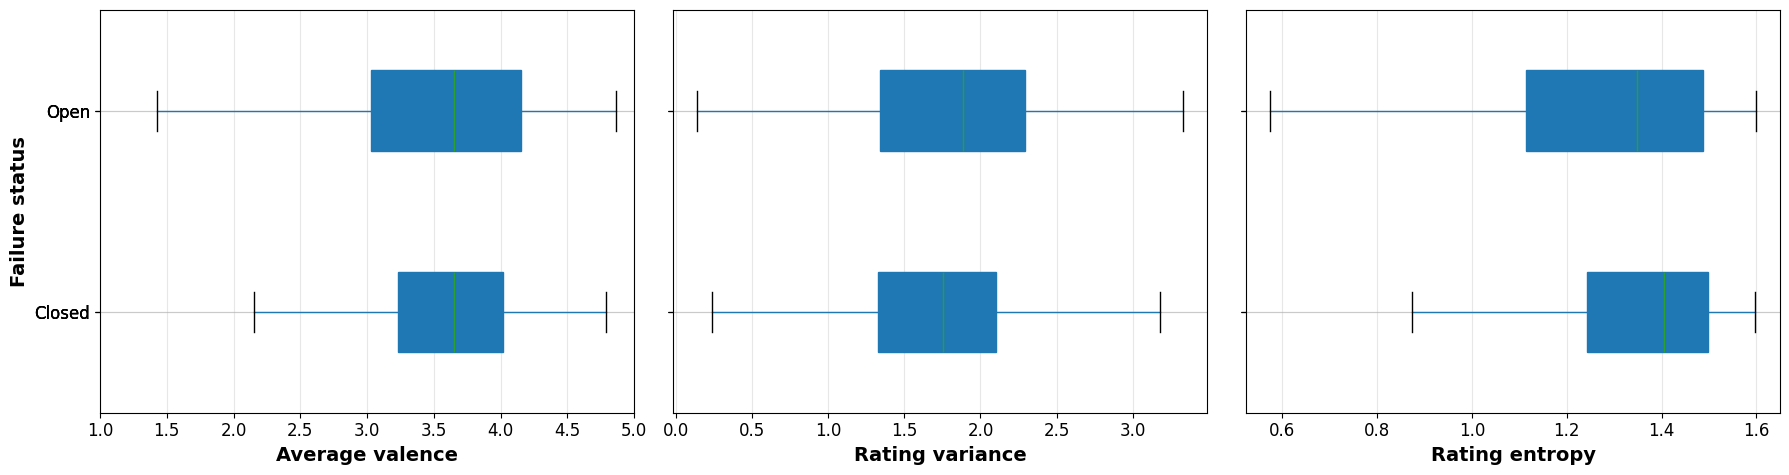


Figure 2 saved to: /Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/assets/rating_statistics_all.png


In [79]:
box_plot(
    business_rating_stats,
    figure_name="rating_statistics_all.png",
    title="Rating distribution across open and closed businesses",
)

### Statistical Tests: Mann-Whitney U Test

Testing for significant differences between open and closed restaurants


In [80]:
from scipy.stats import mannwhitneyu


def mannwhitneyu_test(df):
    # Prepare data for Mann-Whitney U test
    df_clean = df.dropna(subset=["MEAN", "VAR", "ENTR"])
    failure = df_clean[df_clean["Status"] == "Closed"]
    in_business = df_clean[df_clean["Status"] == "Open"]

    print("=" * 80)
    print("MANN-WHITNEY U TEST RESULTS")
    print("=" * 80)

    # Test 1: Average Valence (MEAN)
    stat_mean, p_mean = mannwhitneyu(
        failure["MEAN"], in_business["MEAN"], alternative="two-sided"
    )
    print(f"\n1. Average Valence (MEAN):")
    print(f"   U-statistic: {stat_mean:.2f}")
    print(f"   p-value: {p_mean:.4f}")
    print(f"   Significant: {'Yes' if p_mean < 0.05 else 'No'} (α = 0.05)")

    # Test 2: Rating Variance (VAR)
    stat_var, p_var = mannwhitneyu(
        failure["VAR"], in_business["VAR"], alternative="two-sided"
    )
    print(f"\n2. Rating Variance (VAR):")
    print(f"   U-statistic: {stat_var:.2f}")
    print(f"   p-value: {p_var:.4f}")
    print(f"   Significant: {'Yes' if p_var < 0.05 else 'No'} (α = 0.05)")

    # Test 3: Rating Entropy (ENTR)
    stat_entr, p_entr = mannwhitneyu(
        failure["ENTR"], in_business["ENTR"], alternative="two-sided"
    )
    print(f"\n3. Rating Entropy (ENTR):")
    print(f"   U-statistic: {stat_entr:.2f}")
    print(f"   p-value: {p_entr:.4f}")
    print(f"   Significant: {'Yes' if p_entr < 0.05 else 'No'} (α = 0.05)")

In [81]:
mannwhitneyu_test(business_rating_stats)

MANN-WHITNEY U TEST RESULTS

1. Average Valence (MEAN):
   U-statistic: 78692.50
   p-value: 0.9100
   Significant: No (α = 0.05)

2. Rating Variance (VAR):
   U-statistic: 71421.00
   p-value: 0.0474
   Significant: Yes (α = 0.05)

3. Rating Entropy (ENTR):
   U-statistic: 88235.50
   p-value: 0.0042
   Significant: Yes (α = 0.05)


**Interpretation:**

- **Average Valence (Mean)**: No significant difference in average ratings between open and closed restaurants (p > 0.05)
- **Rating Variance**: Significant difference detected (p < 0.05) - closed restaurants show higher variance in ratings
- **Rating Entropy**: Highly significant difference (p < 0.01) - closed restaurants show higher entropy, indicating more dispersed rating distributions

**Note:** These results are consistent with the original findings: (Naumzik et al.)

- Mean: p-value = 0.91
- Variance: p-value = 0.047
- Entropy: p-value = 0.004


## Rating Trajectories over Time


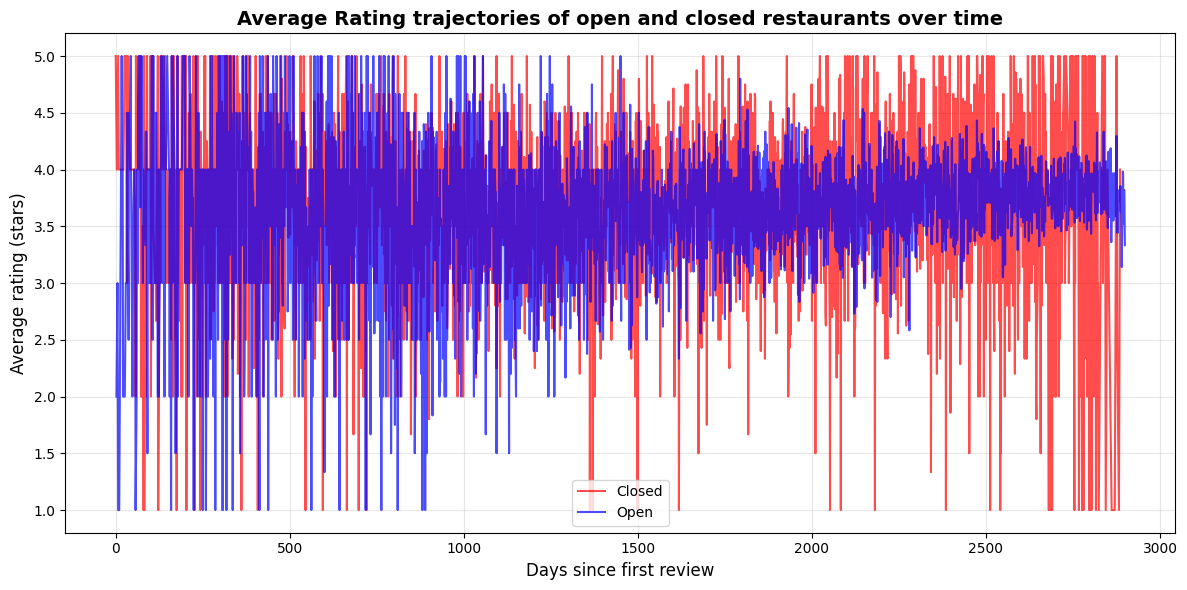

In [82]:
open_restaurants_ids = business_covariates[business_covariates["is_open"] == 1][
    "business_id"
]
closed_restaurant_ids = business_covariates[business_covariates["is_open"] == 0][
    "business_id"
]

# Get reviews for closed restaurants
closed_reviews = reviews[reviews["business_id"].isin(closed_restaurant_ids)]

# Get reviews for open restaurants
open_reviews = reviews[reviews["business_id"].isin(open_restaurants_ids)]

# Calculate average ratings per date for closed and open restaurants

# For closed restaurants
avg_closed = closed_reviews.groupby("date")["stars"].mean().reset_index()
avg_closed["is_open"] = 0

# For open restaurants
avg_open = open_reviews.groupby("date")["stars"].mean().reset_index()
avg_open["is_open"] = 1

# Combine for trajectory plot
plot_data = pd.concat([avg_closed, avg_open], ignore_index=True)
plot_data = plot_data.sort_values(by="date")

# Calculate days since the first review
plot_data["days_since_first"] = (
    pd.to_datetime(plot_data["date"]) - pd.to_datetime(plot_data["date"]).min()
).dt.days


plt.figure(figsize=(12, 6))

for label, color in zip([0, 1], ["red", "blue"]):
    data = plot_data[plot_data["is_open"] == label]
    plt.plot(
        data["days_since_first"],
        data["stars"],
        label="Closed" if label == 0 else "Open",
        color=color,
        alpha=0.7,
    )

plt.xlabel("Days since first review", fontsize=12)
plt.ylabel("Average rating (stars)", fontsize=12)
plt.title(
    "Average Rating trajectories of open and closed restaurants over time",
    fontsize=14,
    fontweight="bold",
)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    ASSETS_FOLDER / "rating_trajectories.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.tight_layout()
plt.show()

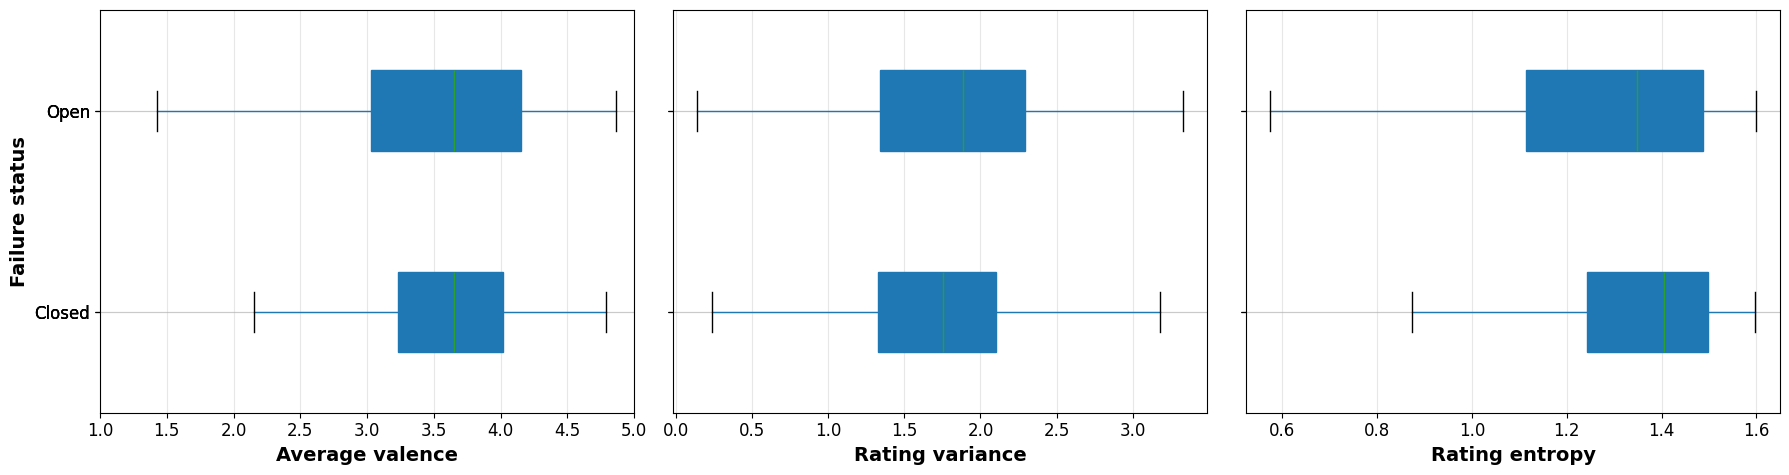


Figure 2 saved to: /Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/assets/rating_statistics_last_1000.png


In [83]:
box_plot(
    business_rating_stats_last1000,
    figure_name="rating_statistics_last_1000.png",
    title="Rating distribution across open and closed businesses (last 1000 ratings)",
)